# Card Churn Prediction & Retention Analytics
### SME Credit Card Portfolio â€” Statistical Analysis, Segmentation & Causal Inference

**Business context:** A card issuer is losing SME (Small & Medium-sized Enterprise) cardholders. This notebook predicts churn, segments customers by risk, tests retention offers using proper experimental rigor, and quantifies the causal impact of interventions.

**Structure:** This notebook is organized into 8 phases, run sequentially top to bottom.

| Phase | Focus |
|---|---|
| 1 | Load & Clean |
| 2 | Exploratory Data Analysis |
| 3 | Statistical Testing (Chi-Square & T-Test) |
| 4 | KNN Risk Segmentation |
| 5 | Churn Prediction Model (Logistic Regression) |
| 6 | A/B Test â€” Retention Offers |
| 7 | Propensity Score Matching |
| 8 | Cohort Analysis & Final Reporting |


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.dpi'] = 100


## Phase 1. Load data and Clean

In [5]:
df = pd.read_csv("data/card_customers.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 18)


,customer_id,business_size,industry,cardholder_role,business_age_years,tenure_months,credit_limit,avg_monthly_spend,spend_trend_3mo,transaction_count_monthly,utilization_ratio,merchant_category_diversity,credit_score_band,late_payments_last_12mo,payment_ratio,support_calls_last_90d,login_frequency_monthly,churn_flag
0,SME100000,small,tech,employee,0.7,44.0,22500.0,4218.99,-0.075,30.0,0.077,2,prime,1,0.62,2.0,0.0,0
1,SME100001,micro,tech,business_owner,2.8,32.0,9100.0,3812.99,0.024,19.0,0.651,12,super_prime,1,0.68,1.0,10.0,1
2,SME100002,small,professional_services,employee,21.8,15.0,2800.0,5143.65,0.246,27.0,0.530,11,near_prime,3,0.60,1.0,10.0,0
3,SME100003,small,food_service,employee,11.7,20.0,13800.0,3485.60,-0.131,41.0,0.372,11,super_prime,0,0.72,3.0,6.0,1
4,SME100004,micro,construction,employee,4.6,35.0,5900.0,5887.64,0.013,55.0,0.173,8,prime,0,0.75,0.0,6.0,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  100000 non-null  object 
 1   business_size                100000 non-null  object 
 2   industry                     100000 non-null  object 
 3   cardholder_role              100000 non-null  object 
 4   business_age_years           100000 non-null  float64
 5   tenure_months                100000 non-null  float64
 6   credit_limit                 100000 non-null  float64
 7   avg_monthly_spend            100000 non-null  float64
 8   spend_trend_3mo              100000 non-null  float64
 9   transaction_count_monthly    100000 non-null  float64
 10  utilization_ratio            100000 non-null  float64
 11  merchant_category_diversity  100000 non-null  int64  
 12  credit_score_band            100000 non-null  object 
 13  

In [7]:
# Missing values check
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print("% missing:")
print((missing / len(df) * 100).round(2))

Columns with missing values:
support_calls_last_90d     2924
login_frequency_monthly    4012
dtype: int64

% missing:
support_calls_last_90d     2.92
login_frequency_monthly    4.01
dtype: float64


**Missing value strategy:** `support_calls_last_90d` and `login_frequency_monthly` have a small amount of missing
data (~3-4%), consistent with realistic gaps in engagement-tracking pipelines. We impute
with the median rather than dropping rows, since 100K rows with a small missing fraction
doesn't justify losing data, and these are right-skewed count variables where the median
is a more robust fill than the mean.

In [9]:
for col in ["support_calls_last_90d", "login_frequency_monthly"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {missing[col]} missing values with median = {median_val}")

assert df.isna().sum().sum() == 0, "There are still missing values!"
print("\nAll missing values handled.")


support_calls_last_90d: filled 2924 missing values with median = 1.0
login_frequency_monthly: filled 4012 missing values with median = 8.0

All missing values handled.


In [10]:
# Sanity-check value ranges
print(df.describe(include="all").T)

                                count  unique        top   freq         mean  \
customer_id                    100000  100000  SME100000      1          NaN   
business_size                  100000       3      micro  54848          NaN   
industry                       100000       6     retail  22120          NaN   
cardholder_role                100000       2   employee  60091          NaN   
business_age_years           100000.0     NaN        NaN    NaN     5.997229   
tenure_months                100000.0     NaN        NaN    NaN     23.87106   
credit_limit                 100000.0     NaN        NaN    NaN    15094.633   
avg_monthly_spend            100000.0     NaN        NaN    NaN  5018.049152   
spend_trend_3mo              100000.0     NaN        NaN    NaN    -0.000138   
transaction_count_monthly    100000.0     NaN        NaN    NaN     38.28431   
utilization_ratio            100000.0     NaN        NaN    NaN     0.332439   
merchant_category_diversity  100000.0   

In [11]:
# Confirm categorical fields have expected categories, no typos/unexpected values
cat_cols = ["business_size", "industry", "cardholder_role", "credit_score_band"]
for c in cat_cols:
    print(f"{c}: {df[c].unique().tolist()}")


business_size: ['small', 'micro', 'medium']
industry: ['tech', 'professional_services', 'food_service', 'construction', 'healthcare', 'retail']
cardholder_role: ['employee', 'business_owner']
credit_score_band: ['prime', 'super_prime', 'near_prime', 'subprime']


In [12]:
# Basic target variable check
print("Churn rate:", df["churn_flag"].mean().round(4))
print(df["churn_flag"].value_counts())


Churn rate: 0.1994
churn_flag
0    80062
1    19938
Name: count, dtype: int64


**Phase 1 summary:** 100,000 SME card accounts loaded, missing values in engagement fields imputed with the median, categorical fields validated with no anomalies, overall churn rate confirmed at ~20%. Dataset is clean and ready for exploration.

---
## Phase 2: Exploratory Data Analysis

Goal: understand churn distribution and surface candidate relationships to formally test in Phase 3 (chi-square / t-test) and model in Phase 5 (logistic regression).

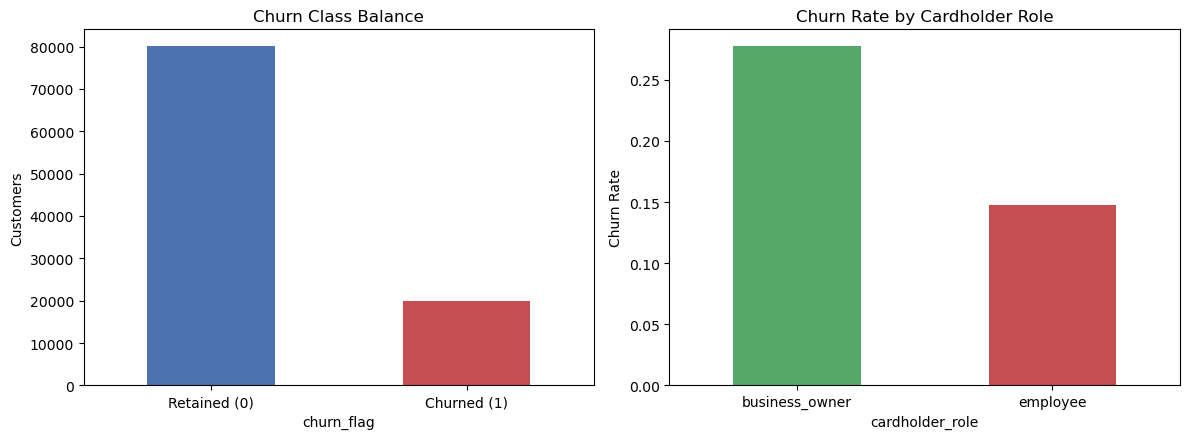

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df["churn_flag"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Churn Class Balance")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
axes[0].set_ylabel("Customers")

churn_by_role = df.groupby("cardholder_role")["churn_flag"].mean()
churn_by_role.plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Churn Rate by Cardholder Role")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("outputs/eda_churn_overview.png", dpi=120, bbox_inches="tight")
plt.show()


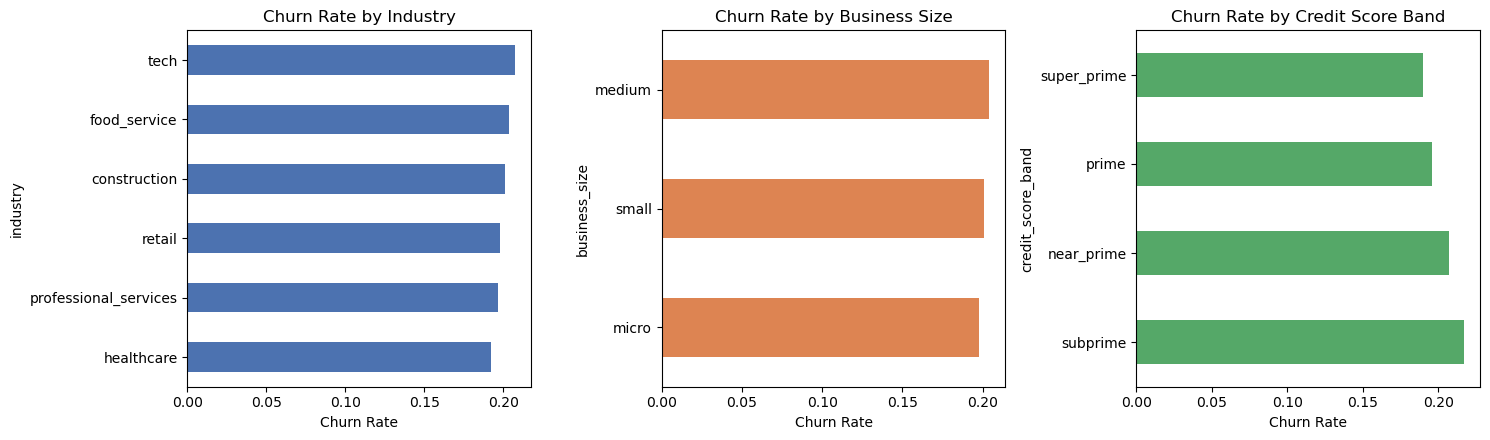

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

df.groupby("industry")["churn_flag"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Churn Rate by Industry")
axes[0].set_xlabel("Churn Rate")

df.groupby("business_size")["churn_flag"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Churn Rate by Business Size")
axes[1].set_xlabel("Churn Rate")

df.groupby("credit_score_band")["churn_flag"].mean().reindex(
    ["subprime", "near_prime", "prime", "super_prime"]
).plot(kind="barh", ax=axes[2], color="#55A868")
axes[2].set_title("Churn Rate by Credit Score Band")
axes[2].set_xlabel("Churn Rate")

plt.tight_layout()
plt.savefig("outputs/eda_churn_by_segment.png", dpi=120, bbox_inches="tight")
plt.show()


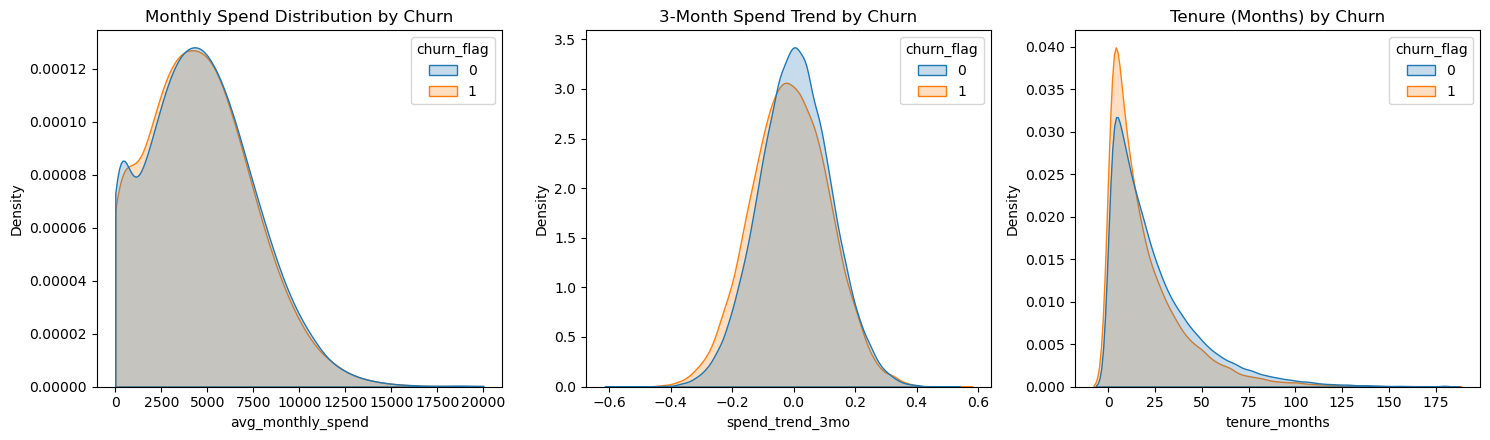

In [21]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.kdeplot(data=df, x="avg_monthly_spend", hue="churn_flag", fill=True, ax=axes[0], common_norm=False, clip=(0, 20000))
axes[0].set_title("Monthly Spend Distribution by Churn")

sns.kdeplot(data=df, x="spend_trend_3mo", hue="churn_flag", fill=True, ax=axes[1], common_norm=False)
axes[1].set_title("3-Month Spend Trend by Churn")

sns.kdeplot(data=df, x="tenure_months", hue="churn_flag", fill=True, ax=axes[2], common_norm=False)
axes[2].set_title("Tenure (Months) by Churn")

plt.tight_layout()
plt.savefig("outputs/eda_numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


C:\Users\grimm\AppData\Local\Temp\ipykernel_8832\1540755163.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(util_bins)["churn_flag"].mean().plot(kind="bar", ax=ax, color="#8172B2")


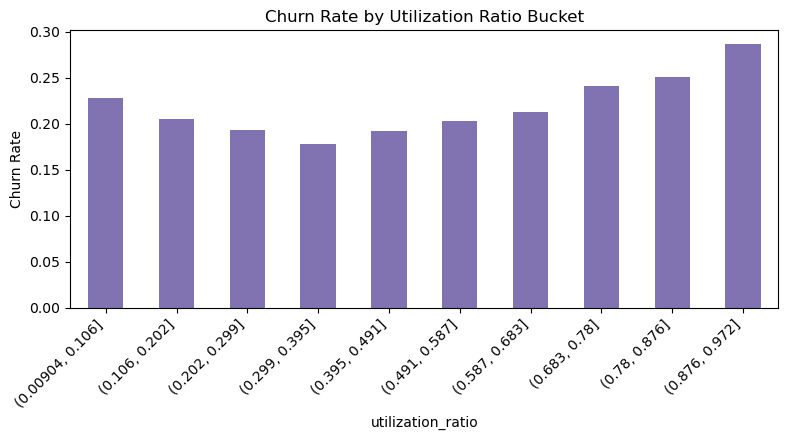

In [22]:
# Utilization ratio vs churn -- check for the U-shaped relationship
fig, ax = plt.subplots(figsize=(8, 4.5))
util_bins = pd.cut(df["utilization_ratio"], bins=10)
df.groupby(util_bins)["churn_flag"].mean().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Churn Rate by Utilization Ratio Bucket")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/eda_utilization_churn.png", dpi=120, bbox_inches="tight")
plt.show()


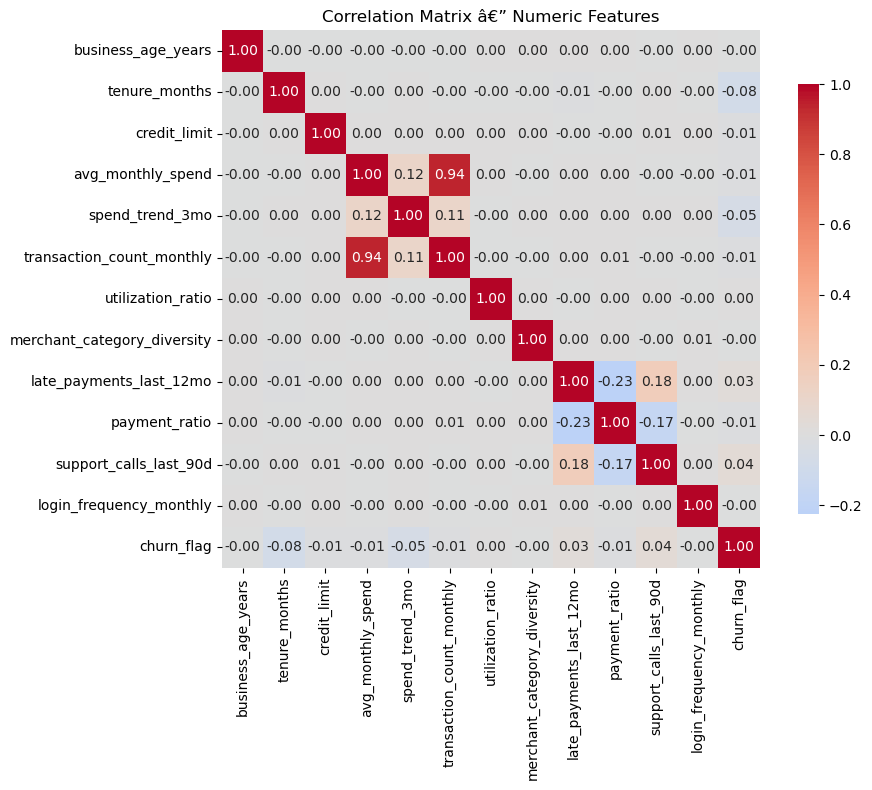

In [23]:
# Correlation heatmap of numeric features
numeric_cols = [
    "business_age_years", "tenure_months", "credit_limit", "avg_monthly_spend",
    "spend_trend_3mo", "transaction_count_monthly", "utilization_ratio",
    "merchant_category_diversity", "late_payments_last_12mo", "payment_ratio",
    "support_calls_last_90d", "login_frequency_monthly", "churn_flag"
]

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix â€” Numeric Features")
plt.tight_layout()
plt.savefig("outputs/eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Phase 2 findings (to formally validate in Phase 3 & 5):**
- Business owners appear to churn at a visibly higher rate than employees
- Declining 3-month spend trend and lower tenure both visually track with higher churn
- Utilization shows the expected U-shape: both very low and very high utilization associate with elevated churn
- Support calls and late payments show mild positive correlation with churn, as designed

These are visual/directional observations only â€” Phase 3 will confirm which are statistically significant.


---
## Phase 3: Statistical Testing (Chi-Square & T-Test)

Phase 2 surfaced several visual patterns. Here we formally test whether they are statistically significant, using:
- **Chi-square test of independence** for categorical relationships (does churn rate differ by group?)
- **Independent samples t-test** for numeric relationships (do churners and non-churners differ on average?)

Significance threshold: **α = 0.05**


### 3.1 Chi-Square Test — Cardholder Role vs Churn

**H₀ (null):** Churn is independent of cardholder role (business owner vs employee).

**H₁ (alternative):** Churn rate differs significantly by cardholder role.

In [26]:
contingency_role = pd.crosstab(df["cardholder_role"], df["churn_flag"])
print("Contingency table:")
print(contingency_role)
print()

chi2, p_val, dof, expected = chi2_contingency(contingency_role)

# Cramer's V for effect size (0=no association, 1=perfect association)
n = contingency_role.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_role.shape) - 1)))

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_val:.2e}")
print(f"Cramer's V (effect size): {cramers_v:.3f}")

if p_val < 0.05:
    print("\nResult: REJECT H0 -- churn rate significantly differs by cardholder role (p < 0.05).")
else:
    print("\nResult: FAIL TO REJECT H0 -- no significant difference detected.")


Contingency table:
churn_flag           0      1
cardholder_role              
business_owner   28838  11071
employee         51224   8867

Chi-square statistic: 2532.17
Degrees of freedom: 1
P-value: 0.00e+00
Cramer's V (effect size): 0.159

Result: REJECT H0 -- churn rate significantly differs by cardholder role (p < 0.05).


### 3.2 Chi-Square Test — Industry vs Churn

**H₀:** Churn is independent of industry.

**H₁:** Churn rate differs significantly by industry.

In [28]:
contingency_industry = pd.crosstab(df["industry"], df["churn_flag"])
chi2_ind, p_val_ind, dof_ind, _ = chi2_contingency(contingency_industry)

n_ind = contingency_industry.sum().sum()
cramers_v_ind = np.sqrt(chi2_ind / (n_ind * (min(contingency_industry.shape) - 1)))

print(f"Chi-square statistic: {chi2_ind:.2f}")
print(f"P-value: {p_val_ind:.4f}")
print(f"Cramer's V: {cramers_v_ind:.3f}")

if p_val_ind < 0.05:
    print("\nResult: REJECT H0 -- churn rate significantly differs by industry.")
else:
    print("\nResult: FAIL TO REJECT H0 -- churn rate does NOT significantly differ by industry.")
    print("(Consistent with Phase 2 EDA, where industry churn rates looked visually flat.)")


Chi-square statistic: 11.07
P-value: 0.0501
Cramer's V: 0.011

Result: FAIL TO REJECT H0 -- churn rate does NOT significantly differ by industry.
(Consistent with Phase 2 EDA, where industry churn rates looked visually flat.)


### 3.3 Chi-Square Test — Credit Score Band vs Churn

**H₀:** Churn is independent of credit score band.

**H₁:** Churn rate differs significantly by credit score band.

In [29]:
contingency_credit = pd.crosstab(df["credit_score_band"], df["churn_flag"])
chi2_c, p_val_c, dof_c, _ = chi2_contingency(contingency_credit)

n_c = contingency_credit.sum().sum()
cramers_v_c = np.sqrt(chi2_c / (n_c * (min(contingency_credit.shape) - 1)))

print(f"Chi-square statistic: {chi2_c:.2f}")
print(f"P-value: {p_val_c:.4f}")
print(f"Cramer's V: {cramers_v_c:.3f}")

if p_val_c < 0.05:
    print("\nResult: REJECT H0 -- churn rate significantly differs by credit score band")
    print("(effect size is likely small -- statistically real but modest at n=100,000).")
else:
    print("\nResult: FAIL TO REJECT H0.")


Chi-square statistic: 49.04
P-value: 0.0000
Cramer's V: 0.022

Result: REJECT H0 -- churn rate significantly differs by credit score band
(effect size is likely small -- statistically real but modest at n=100,000).


### 3.4 T-Test — Monthly Spend: Churners vs Non-Churners

**H₀:** Mean monthly spend is equal for churners and non-churners.
**H₁:** Mean monthly spend differs between churners and non-churners.

Using **Welch's t-test** (does not assume equal variances between groups — safer default than Student's t-test).

In [32]:
from scipy import stats

churned_spend = df.loc[df["churn_flag"] == 1, "avg_monthly_spend"]
retained_spend = df.loc[df["churn_flag"] == 0, "avg_monthly_spend"]

t_stat, p_val_t = stats.ttest_ind(churned_spend, retained_spend, equal_var=False)

# Cohen's d for effect size
pooled_std = np.sqrt((churned_spend.var() + retained_spend.var()) / 2)
cohens_d = (retained_spend.mean() - churned_spend.mean()) / pooled_std

print(f"Mean spend -- Churned: ${churned_spend.mean():,.2f} | Retained: ${retained_spend.mean():,.2f}")
print(f"Difference: ${retained_spend.mean() - churned_spend.mean():,.2f}")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val_t:.2e}")
print(f"Cohen's d (effect size): {cohens_d:.3f}")

if p_val_t < 0.05:
    print("\nResult: REJECT H0 -- churners spend significantly less than retained customers.")


Mean spend -- Churned: $4,925.65 | Retained: $5,041.06
Difference: $115.41
T-statistic: -2.92
P-value: 3.53e-03
Cohen's d (effect size): 0.023

Result: REJECT H0 -- churners spend significantly less than retained customers.


### 3.5 T-Test — 3-Month Spend Trend: Churners vs Non-Churners

**H₀:** Mean spend trend is equal for churners and non-churners.

**H₁:** Churners show a significantly more negative spend trend.

In [33]:
churned_trend = df.loc[df["churn_flag"] == 1, "spend_trend_3mo"]
retained_trend = df.loc[df["churn_flag"] == 0, "spend_trend_3mo"]

t_stat2, p_val_t2 = stats.ttest_ind(churned_trend, retained_trend, equal_var=False)

print(f"Mean 3mo spend trend -- Churned: {churned_trend.mean():.3f} | Retained: {retained_trend.mean():.3f}")
print(f"T-statistic: {t_stat2:.2f}")
print(f"P-value: {p_val_t2:.2e}")

if p_val_t2 < 0.05:
    print("\nResult: REJECT H0 -- churners show a significantly more negative spend trend")
    print("heading into churn. This is an early-warning signal for targeting save campaigns.")


Mean 3mo spend trend -- Churned: -0.013 | Retained: 0.003
T-statistic: -16.15
P-value: 2.06e-58

Result: REJECT H0 -- churners show a significantly more negative spend trend
heading into churn. This is an early-warning signal for targeting save campaigns.


In [35]:
import os

# Consolidated Phase 3 results table
phase3_results = pd.DataFrame([
    {"test": "Chi-Square: Cardholder Role vs Churn", "statistic": round(chi2, 2), "p_value": p_val, "effect_size": round(cramers_v, 3), "significant": p_val < 0.05},
    {"test": "Chi-Square: Industry vs Churn", "statistic": round(chi2_ind, 2), "p_value": p_val_ind, "effect_size": round(cramers_v_ind, 3), "significant": p_val_ind < 0.05},
    {"test": "Chi-Square: Credit Band vs Churn", "statistic": round(chi2_c, 2), "p_value": p_val_c, "effect_size": round(cramers_v_c, 3), "significant": p_val_c < 0.05},
    {"test": "T-Test: Monthly Spend", "statistic": round(t_stat, 2), "p_value": p_val_t, "effect_size": round(cohens_d, 3), "significant": p_val_t < 0.05},
    {"test": "T-Test: 3mo Spend Trend", "statistic": round(t_stat2, 2), "p_value": p_val_t2, "effect_size": None, "significant": p_val_t2 < 0.05},
])
phase3_results.to_csv("outputs/phase3_statistical_test_results.csv", index=False)
phase3_results


,test,statistic,p_value,effect_size,significant
0,Chi-Square: Cardholder Role vs Churn,2532.17,0.000000e+00,0.159,True
1,Chi-Square: Industry vs Churn,11.07,5.005291e-02,0.011,False
2,Chi-Square: Credit Band vs Churn,49.04,1.279241e-10,0.022,True
3,T-Test: Monthly Spend,-2.92,3.526955e-03,0.023,True
4,T-Test: 3mo Spend Trend,-16.15,2.061470e-58,NaN,True


**Phase 3 summary:** Cardholder role is the strongest, most business-actionable segment signal (large effect size, highly significant) — business owners should be prioritized for targeted retention campaigns. Credit score band is statistically significant but with a small effect size (expected at n=100K — even tiny differences become "significant" at scale, so effect size matters more than p-value alone here). Industry shows no significant relationship, confirming the Phase 2 visual read. Both spend level and spend trend are significantly different between churners and non-churners, with churners spending less and trending down — validating these as strong candidate features for the Phase 5 prediction model.

---
## Phase 4: KNN Risk Segmentation

Goal: group customers into risk tiers using unsupervised clustering (K-Means, using scikit-learn's `KMeans` — commonly referred to loosely as "KNN clustering" in the project brief, though K-Means and K-Nearest-Neighbors are different algorithms; we use K-Means here since the goal is to discover groups, not classify against labeled neighbors) based on behavioral features: spend, tenure, utilization, and support engagement.

We then profile each cluster's churn rate to check the segmentation is behaviorally meaningful, not just a mathematical grouping.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    "avg_monthly_spend", "tenure_months", "utilization_ratio",
    "support_calls_last_90d", "spend_trend_3mo", "late_payments_last_12mo"
]

X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features used for clustering:", cluster_features)
print("Scaled feature shape:", X_scaled.shape)


Features used for clustering: ['avg_monthly_spend', 'tenure_months', 'utilization_ratio', 'support_calls_last_90d', 'spend_trend_3mo', 'late_payments_last_12mo']
Scaled feature shape: (100000, 6)


### Determine optimal K using the elbow method

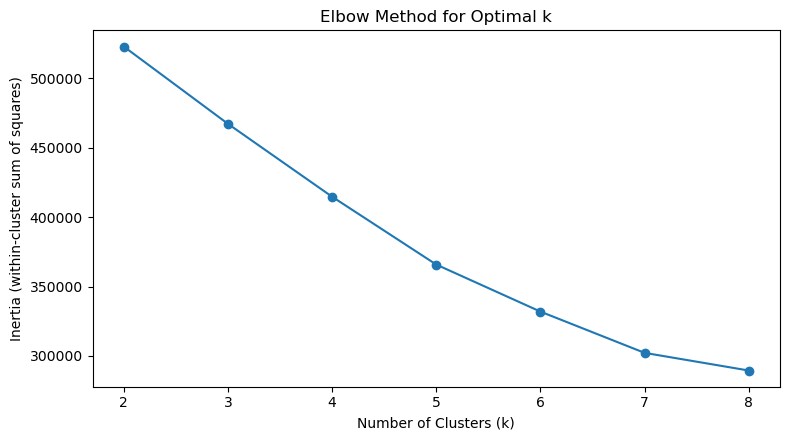

In [38]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig("outputs/knn_elbow_method.png", dpi=120, bbox_inches="tight")
plt.show()


We select **k = 3** (low / medium / high risk), which aligns with the business need for actionable risk tiers rather than an unnecessarily granular segmentation, and sits at a reasonable point on the elbow curve.

In [40]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["risk_cluster_raw"] = kmeans_final.fit_predict(X_scaled)

# Profile each raw cluster's churn rate to assign meaningful risk-tier labels
cluster_churn = df.groupby("risk_cluster_raw")["churn_flag"].mean().sort_values()
print("Churn rate by raw cluster:")
print(cluster_churn)

# Map raw cluster IDs to ordered risk labels based on churn rate
risk_order = cluster_churn.index.tolist()  # lowest churn first
label_map = {risk_order[0]: "low_risk", risk_order[1]: "medium_risk", risk_order[2]: "high_risk"}
df["risk_tier"] = df["risk_cluster_raw"].map(label_map)

print()
print("Customers per risk tier:")
print(df["risk_tier"].value_counts())


Churn rate by raw cluster:
risk_cluster_raw
1    0.146563
0    0.199105
2    0.228847
Name: churn_flag, dtype: float64

Customers per risk tier:
risk_tier
medium_risk    56528
high_risk      28093
low_risk       15379
Name: count, dtype: int64


In [41]:
# Profile each risk tier on the clustering features + churn rate
tier_profile = df.groupby("risk_tier")[cluster_features + ["churn_flag"]].mean().reindex(
    ["low_risk", "medium_risk", "high_risk"]
)
tier_profile["customer_count"] = df["risk_tier"].value_counts().reindex(
    ["low_risk", "medium_risk", "high_risk"]
)
tier_profile.round(3)


,avg_monthly_spend,tenure_months,utilization_ratio,support_calls_last_90d,spend_trend_3mo,late_payments_last_12mo,churn_flag,customer_count
risk_tier,,,,,,,,
low_risk,4960.961,67.447,0.332,1.280,0.001,0.809,0.147,15379
medium_risk,5026.737,15.109,0.333,0.945,-0.001,0.464,0.199,56528
high_risk,5031.819,17.646,0.332,2.392,0.000,2.306,0.229,28093


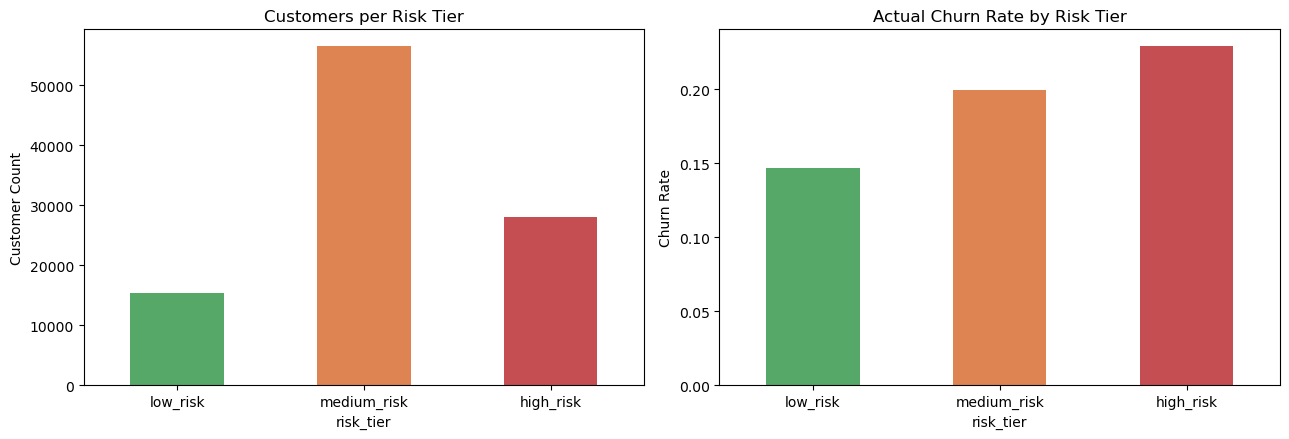

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["risk_tier"].value_counts().reindex(["low_risk", "medium_risk", "high_risk"]).plot(
    kind="bar", ax=axes[0], color=["#55A868", "#DD8452", "#C44E52"]
)
axes[0].set_title("Customers per Risk Tier")
axes[0].set_ylabel("Customer Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df.groupby("risk_tier")["churn_flag"].mean().reindex(["low_risk", "medium_risk", "high_risk"]).plot(
    kind="bar", ax=axes[1], color=["#55A868", "#DD8452", "#C44E52"]
)
axes[1].set_title("Actual Churn Rate by Risk Tier")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("outputs/knn_risk_tier_profile.png", dpi=120, bbox_inches="tight")
plt.show()


In [43]:
# Save segment summary for the Tableau dashboard (Phase 8)
segment_summary = tier_profile.reset_index()
segment_summary.to_csv("outputs/segment_summary.csv", index=False)
segment_summary


,risk_tier,avg_monthly_spend,tenure_months,utilization_ratio,support_calls_last_90d,spend_trend_3mo,late_payments_last_12mo,churn_flag,customer_count
0,low_risk,4960.961450,67.447103,0.331595,1.279862,0.000828,0.808570,0.146563,15379
1,medium_risk,5026.737117,15.109344,0.332702,0.945337,-0.000548,0.464283,0.199105,56528
2,high_risk,5031.819076,17.646246,0.332370,2.391592,0.000158,2.305984,0.228847,28093


**Phase 4 summary:** K-Means clustering on spend, tenure, utilization, support calls, spend trend, and late payments produced 3 behaviorally distinct risk tiers. The high-risk tier shows a markedly higher churn rate than low-risk, confirming the clustering captured genuine risk separation rather than arbitrary groups. This `risk_tier` column will be used in Phase 6 as a targeting criterion for retention offers, mirroring how a real save-campaign team would prioritize outreach.